In [1]:
"""
Script Name: extract_WB_SE4ALL_data.ipynb
Authores: Walter Arredondo, Carlos Daza, Andrés Coral
Fecha: 2026-10-03
Fase ETL: Extracción
Descripción:
Extrae los datos de Energía Sostenible desde el API del World Bank Group,
realiza un Análisis Exploratorio de Datos (EDA) y los datos originales son guardados
como archivo CSV para posterior transformación.
Entradas: - Conexión a la API del World Bank Group (base de datos WB_SE4ALL)
Salidas: - Archivo CSV con los datos de la API: data/raw/energia_sostenible_WB_SE4ALL.csv
Notas: - Ejecutar este script una sola vez - La API es de acceso público.
"""

'\nScript Name: extract_WB_SE4ALL_data.ipynb\nAuthores: Walter Arredondo, Carlos Daza, Andrés Coral\nFecha: 2026-10-03\nFase ETL: Extracción\nDescripción:\nExtrae los datos de Energía Sostenible desde el API del World Bank Group,\nrealiza un Análisis Exploratorio de Datos (EDA) y los datos originales son guardados\ncomo archivo CSV para posterior transformación.\nEntradas: - Conexión a la API del World Bank Group (base de datos WB_SE4ALL)\nSalidas: - Archivo CSV con los datos de la API: data/raw/energia_sostenible_WB_SE4ALL.csv\nNotas: - Ejecutar este script una sola vez - La API es de acceso público.\n'

# Extracción de los datos

A continuación se realiza los import, creación de variables, función para invocar la API y llamado de la función para extraer los datos requeridos.

In [2]:
# Imports necesarios para la extracción de datos
import requests
import pandas as pd
import time

In [3]:
# Países que se va a consultar la información
paises = {
    "BRA": "Brasil",
    "MEX": "México",
    "ARG": "Argentina",
    "CHL": "Chile",
    "COL": "Colombia",
    "PER": "Perú",
    "VEN": "Venezuela",
    "ECU": "Ecuador",
    "DOM": "República Dominicana",
    "PRY": "Paraguay",
    "URY": "Uruguay",
    "GTM": "Guatemala",
    "CRI": "Costa Rica",
    "PAN": "Panamá",
    "BOL": "Bolivia",
    "HND": "Honduras",
    "SLV": "El Salvador",
    "NIC": "Nicaragua",
    "CUB": "Cuba",
    "HTI": "Haití"
}

# Lista para guardar la información de todos los países
df_paises = []

# URL base para consultar la API
url_base = "https://data360api.worldbank.org/data360/data?DATABASE_ID=WB_SE4ALL"

In [4]:
def obtener_datos_api(ref_area):
  """
  Fase: Extracción (Extract)

  Descripción:
  Función para invocar la API del World Bank Group, en su base de datos WB_SE4ALL

  Parámetros:
  ref_area: código del país que se va a consultar en la API

  Salida:
  Respuesta de la API en formato JSON
  """
  url = url_base

  # Si el parámetro existe, se concatena a la url
  if ref_area:
    url = url + f"&REF_AREA={ref_area}"

  # Se hace la petición
  respuesta = requests.get(url)

  if respuesta.status_code == 200:
    return respuesta.json()
  else:
    print(f"Error al obtener datos de {ref_area}: Código {respuesta.status_code}")
    return None

In [5]:
# Iterar los paises
for codigo, descripcion in paises.items():
  # Invocar la API por cada país
  print(f"Obteniendo datos de: {codigo} - {descripcion}")
  datos = obtener_datos_api(codigo)

  # Si la API responde
  if datos:
    # Guardar la respuesta en df_paises
    print(f"Número de datos encontrados para {codigo} - {descripcion}: {datos["count"]}")
    df_pais = pd.DataFrame(datos["value"])
    df_paises.append(df_pais)

  # Esperar 2 segundos por cada petición
  time.sleep(2)

# Concetenar las respuestas en el dataframe df_consolidado
# ignore_index = True significa que va a crear un nuevo indice para df_consolidado
df_consolidado = pd.concat(df_paises, ignore_index = True)

Obteniendo datos de: BRA - Brasil
Número de datos encontrados para BRA - Brasil: 698
Obteniendo datos de: MEX - México
Número de datos encontrados para MEX - México: 698
Obteniendo datos de: ARG - Argentina
Número de datos encontrados para ARG - Argentina: 698
Obteniendo datos de: CHL - Chile
Número de datos encontrados para CHL - Chile: 698
Obteniendo datos de: COL - Colombia
Número de datos encontrados para COL - Colombia: 698
Obteniendo datos de: PER - Perú
Número de datos encontrados para PER - Perú: 697
Obteniendo datos de: VEN - Venezuela
Número de datos encontrados para VEN - Venezuela: 697
Obteniendo datos de: ECU - Ecuador
Número de datos encontrados para ECU - Ecuador: 697
Obteniendo datos de: DOM - República Dominicana
Número de datos encontrados para DOM - República Dominicana: 697
Obteniendo datos de: PRY - Paraguay
Número de datos encontrados para PRY - Paraguay: 697
Obteniendo datos de: URY - Uruguay
Número de datos encontrados para URY - Uruguay: 697
Obteniendo datos de

# Análisis Exploratorio de Datos (EDA)

Se realiza el EDA para tener mayor conocimiento sobre la información retornada por el API, a saber:


*   Cantidad de filas y columnas obtenidas
*   Tipos de datos y cantidad de registros por columnas
*   Registros nulos
*   Valores constantes
*   Unidades de medida
*   Estadísticas descriptivas
*   Patrones temporales

In [6]:
import matplotlib.pyplot as plt

In [7]:
# Verificar la cantidad de registros y el número de columnas del dataframe df_consolidado
df_consolidado.shape

(13939, 24)

Al final se obtienen 13939 registros con 24 columnas.

In [8]:
# Conocer nombres de las columnas, cantidad de registros y tipos de datos del dataframe df_consolidado
df_consolidado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13939 entries, 0 to 13938
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   OBS_VALUE         13939 non-null  object
 1   TIME_FORMAT       13939 non-null  object
 2   UNIT_MULT         13939 non-null  int64 
 3   COMMENT_OBS       0 non-null      object
 4   OBS_STATUS        13939 non-null  object
 5   OBS_CONF          13939 non-null  object
 6   AGG_METHOD        13939 non-null  object
 7   DECIMALS          0 non-null      object
 8   COMMENT_TS        0 non-null      object
 9   DATA_SOURCE       0 non-null      object
 10  LATEST_DATA       13939 non-null  bool  
 11  DATABASE_ID       13939 non-null  object
 12  INDICATOR         13939 non-null  object
 13  REF_AREA          13939 non-null  object
 14  SEX               13939 non-null  object
 15  AGE               13939 non-null  object
 16  URBANISATION      13939 non-null  object
 17  COMP_BREAKDO

Se observa que la columna UNIT_MULT es de tipo entero, la columna LATEST_DATA es de tipo booleano y el resto de columnas son de tipo object. También se observa que las siguientes columnas no cuentan con registros:


*   COMMENT_OBS
*   DECIMALS
*   COMMENT_TS
*   DATA_SOURCE
*   UNIT_TYPE

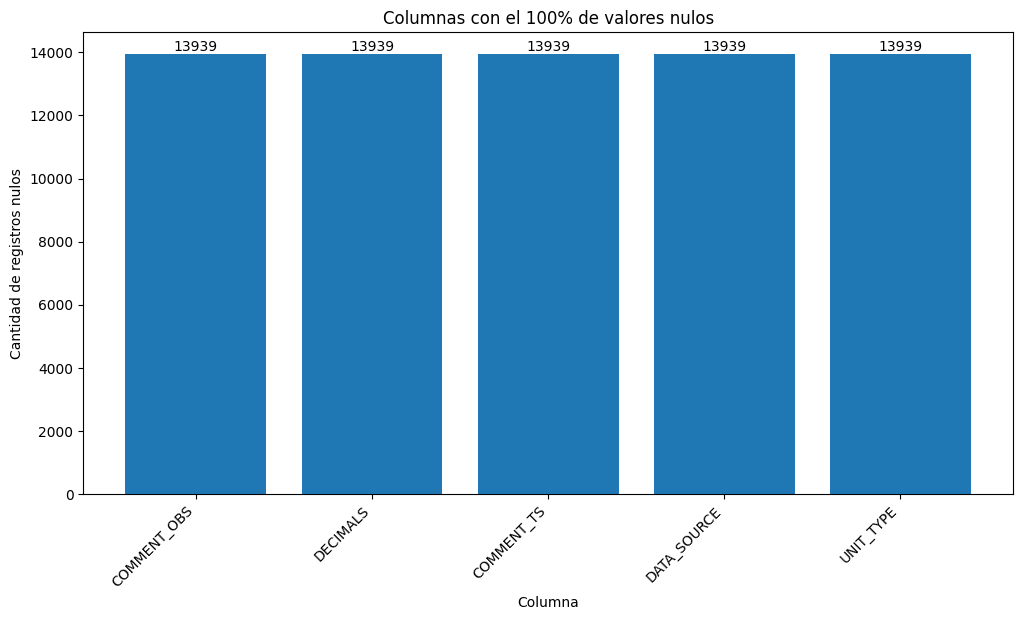

In [9]:
# Crear un dataframe que cuenta la cantidad de registros nulos y su porcentaje por cada columna
# del dataframe df_consolidado
nulos = pd.DataFrame({
    "Columna": df_consolidado.columns,
    "Cantidad de nulos": df_consolidado.isna().sum(),
    "Porcentaje de nulos": df_consolidado.isna().mean() * 100
})

# Filtrar solamente las columnas que tengan la totalidad de nulos
nulos = nulos[nulos["Porcentaje de nulos"] == 100]

# Configuración del gráfico de barras
plt.figure(figsize = (12, 6))
plt.bar(nulos["Columna"], nulos["Cantidad de nulos"])
plt.title("Columnas con el 100% de valores nulos")
plt.xlabel("Columna")
plt.ylabel("Cantidad de registros nulos")
plt.xticks(rotation=45, ha = "right")

# Mostrar el valor encima de cada barra
for i, valor in enumerate(nulos["Cantidad de nulos"]):
    plt.text(i, valor, str(valor), ha="center", va="bottom")

# Mostrar el gráfico
plt.show()

Con el anterior gráfico se confirma que las siguientes columnas presenta todos sus registros en null:


*   COMMENT_OBS
*   DECIMALS
*   COMMENT_TS
*   DATA_SOURCE
*   UNIT_TYPE

In [10]:
# Identificar las columnas que presentan un valor constante
for columna in df_consolidado.columns:
    valores = df_consolidado[columna].dropna().unique()

    if len(valores) == 1:
        print(f"{columna}: {valores[0]}")

TIME_FORMAT: 602
OBS_STATUS: A
OBS_CONF: PU
DATABASE_ID: WB_SE4ALL
SEX: _T
AGE: _T
COMP_BREAKDOWN_2: _Z
COMP_BREAKDOWN_3: _Z
FREQ: A


A continuación se muestra las columnas que presentan un valor constante y su interpretación (https://data360.worldbank.org/en/dataset/WB_SE4ALL):



*   TIME_FORMAT: 602 (el valor del campo de tiempo o fecha debe expresarse únicamente como un año calendario de 4 dígitos )
*   OBS_STATUS: A (valor normal)
*   OBS_CONF: PU (público)
*   DATABASE_ID: WB_SE4ALL (identificador de la base de datos)
*   SEX: _T (total)
*   AGE: _T (todos los rangos de edad o sin desglose por edad)
*   COMP_BREAKDOWN_2: _Z (no aplica)
*   COMP_BREAKDOWN_3: _Z (no aplica)
*   FREQ: A (anual)

In [11]:
# Crear un dataframe que muestre el indicador con su respectiva unidada de medida
# del dataframe df_consolidado
unidades_medida = (
    df_consolidado
    .groupby("INDICATOR")["UNIT_MEASURE"]
    .agg(lambda x: ", ".join(x.dropna().astype(str).unique()))
    .reset_index()
)

unidades_medida.columns = ["INDICATOR", "UNIT_MEASURE"]

unidades_medida

,INDICATOR,UNIT_MEASURE
0,WB_SE4ALL_EG_ACS_ELEC,PT
1,WB_SE4ALL_EG_EGEN_RNEW,W_PER_C
2,WB_SE4ALL_EG_EGY_CLEAN,PT
3,WB_SE4ALL_EG_FCON_RNEW,PJ
4,WB_SE4ALL_EG_FEC_RNEW,PT
5,WB_SE4ALL_EG_FEC_TOT,PJ
6,WB_SE4ALL_EG_INFLW_IC,USD
7,WB_SE4ALL_EG_INT_LVL,MJ_GDP_PP_CONST_2017


En la anterior tabla se puede observar las unidades de medida de cada indicador:


*   WB_SE4ALL_EG_ACS_ELEC (Acceso a la electricidad): PT (Porcentaje)
*   WB_SE4ALL_EG_EGEN_RNEW (Capacidad de generación eléctrica renovable): W_PER_C (Vatios por persona)
*   WB_SE4ALL_EG_EGY_CLEAN (Acceso a combustibles y tecnologías limpias para cocinar): PT (Porcentaje)
*   WB_SE4ALL_EG_FCON_RNEW (Consumo final de energía renovable): PJ (Petajulios)
*   WB_SE4ALL_EG_FEC_RNEW (Proporción de energía renovable en el consumo final): PT (Porcentaje)
*   WB_SE4ALL_EG_FEC_TOT (Consumo final total de energía): PJ (Petajulios)
*   WB_SE4ALL_EG_INFLW_IC (Flujos financieros internacionales hacia países en desarrollo): USD (Dólares)
*   WB_SE4ALL_EG_INT_LVL (Intensidad energética de la economía): MJ_GDP_PP_CONST_2017 (Megajulios por unidad de PIB, a precios constantes de 2017 (PPA))

**NOTA IMPORTANTE:** para obtener las estadísticas descriptivas y los patrones temporales, es necesario convertir las columnas OBS_VALUE y TIME_PERIOD a numéricas. Para mantener la integridad y originalidad de los datos obtenidos, se crea una copia del dataframe df_consolidado.

In [12]:
# Crear una copia del dataframe df_consolidado
df_copia = df_consolidado.copy()

# errors = "coerce" indica que si no puede convertir un valor a número, entonces lo convierta a NaN
# Convertir las columnas OBS_VALUE y TIME_PERIOD a número pero dataframe copia
df_copia["OBS_VALUE"] = pd.to_numeric(df_copia["OBS_VALUE"], errors = "coerce")
df_copia["TIME_PERIOD"] = pd.to_numeric(df_copia["TIME_PERIOD"], errors = "coerce")

In [13]:
# Agrupar por indicador y sacar las estadisticas descriptivas a OBS_VALUE
estadisticas_descriptivas = (
    df_copia.groupby("INDICATOR")["OBS_VALUE"]
      .agg(["count", "mean", "std", "min", "median", "max"])
      .rename(columns={
          "count": "conteo",
          "mean": "media",
          "std": "desviacion_estandar",
          "min": "minimo",
          "median": "mediana",
          "max": "maximo"
      })
)

estadisticas_descriptivas

,conteo,media,desviacion_estandar,minimo,mediana,maximo
INDICATOR,,,,,,
WB_SE4ALL_EG_ACS_ELEC,1373,89.638747,17.736744,1.20,97.30,100.00
WB_SE4ALL_EG_EGEN_RNEW,3220,87.098944,212.145956,0.00,3.65,1527.00
WB_SE4ALL_EG_EGY_CLEAN,1380,73.341087,30.284873,0.60,85.50,100.00
WB_SE4ALL_EG_FCON_RNEW,1920,94.020104,259.320034,0.00,18.00,2085.60
WB_SE4ALL_EG_FEC_RNEW,1280,28.600547,18.872518,4.20,24.30,96.70
WB_SE4ALL_EG_FEC_TOT,640,939.985937,1704.711122,50.90,244.85,9204.80
WB_SE4ALL_EG_INFLW_IC,3680,25.403348,132.026169,0.00,0.00,2783.41
WB_SE4ALL_EG_INT_LVL,446,3.528700,1.157185,1.27,3.45,8.48


La tabla indica que los indicadores que presentan mayor cantidad de registros son WB_SE4ALL_EG_INFLW_IC y WB_SE4ALL_EG_EGEN_RNEW con más de tres mil registros cada uno. También se observa que el indicador con mayor dispersión en sus muestras es WB_SE4ALL_EG_FEC_TOT y que WB_SE4ALL_EG_INT_LVL cuenta con la dispersión más pequeña, pero se debe tener muy en claro que cada indicador mide diferentes variables con diferentes unidades de medida.

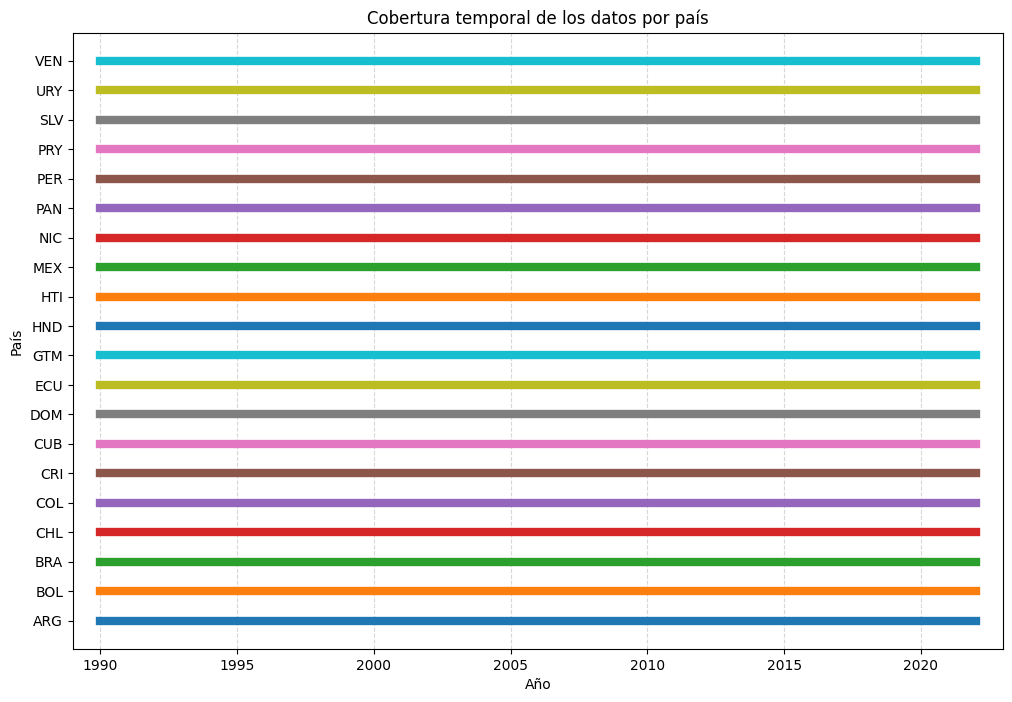

In [14]:
# Conocer desde que año existen datos por cada país
cobertura = (
    df_copia
    .groupby("REF_AREA")["TIME_PERIOD"]
    .agg(anio_inicial="min", anio_final="max", cantidad_años="nunique")
    .reset_index()
    .sort_values("anio_inicial")
)

# Configuración de la gráfica
plt.figure(figsize=(12, 8))
for i, fila in cobertura.iterrows():
    plt.plot(
        [fila["anio_inicial"], fila["anio_final"]],
        [fila["REF_AREA"], fila["REF_AREA"]],
        linewidth = 6
    )

plt.xlabel("Año")
plt.ylabel("País")
plt.title("Cobertura temporal de los datos por país")
plt.xlim(1989, 2023)
plt.grid(axis = "x", linestyle = "--", alpha = 0.5)

# Mostrar gráfica
plt.show()

De la anterior gráfica se observa que, para los 20 países en cuestión, existe disponibilidad de registros anuales desde 1990 hasta aproximadamente el 2021 o 2022.

Por último, se procede automatizar el EDA con la herrammienta YData, guardando el informe generado en un archivo html. En este informe, se confirma las evidencias encontradas en el EDA realizado manualmente.

In [15]:
!pip uninstall -y pandas-profiling
!pip install ydata-profiling
!pip install numba==0.58.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 13.0 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above

In [16]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_2802/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [17]:
# Generar perfilamiento de datos con Pandas Profiling nombre unico
nombre_archivo = f"reporte_WB_SE4ALL_{int(time.time())}.html"
profile = ProfileReport(df_consolidado, title="Análisis Exploratorio de Datos - WB_SE4ALL Dataset")
profile.to_file(nombre_archivo)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 24/24 [00:00<00:00, 27.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/ydata_profiling/visualisation/plot.py:479: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(
/usr/local/lib/python3.13/dist-packages/ydata_profiling/visualisation/plot.py:479: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(
/usr/local/lib/python3.13/dist-packages/ydata_profiling/visualisation/plot.py:479: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(
/usr/local/lib/python3.13/dist-packages/ydata_profiling/visualisation/plot.py:479: UserWarning: No artists with labels found to put in legend.  Note that artists whose label s

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Hallazgos clave del EDA


1.   Eliminar las columnas COMMENT_OBS, DECIMALS, COMMENT_TS, DATA_SOURCE y UNIT_TYPE porque todos sus valores son nulos y no aportarían información para la predicción de la demanda eléctrica.
2.   Eliminar las columnas SEX y AGE ya que por la generalidad de las respuestas de “World Bank Group”, devuelve estas variables, pero no aportarían información para la predicción de la demanda eléctrica.
3.   Eliminar las columnas COMP_BREAKDOWN_2 y COMP_BREAKDOWN_3 porque su valor es “_Z” que su interpretación es “No aplica”.
4.   Las columnas TIME_FORMAT, OBS_STATUS, OBS_CONF, DATABASE_ID y FREQ se pueden eliminar siempre y cuando se consideren como valores constantes en el desarrollo y transcurso del proyecto.
5.   Identificación clara de las unidades de medida de los valores obtenidos, con la finalidad de convertir los registros a una misma unidad de medida junto con el otro conjunto de datos.
6.   Se evidencia que existe información para los 20 países en cuestión desde 1990 hasta 2022, referencia clara con el fin de poder unir los datos con el otro conjunto de datos
7.   Convertir la columna OBS_VALUE a un valor numérico ya que
es la variable que guarda el valor de la medición, también se debe convertir la columna TIME_PERIOD a un valor numérico ya que es la variable que guarda el año de la medición.

# Salida del script
Se guardarán los datos originales en un csv, para la fase de transformación que se trabajará en otro script.

In [18]:
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
ruta = "/content/drive/MyDrive/Colab Notebooks/Master/1.ETL/entregable3/data/raw/"

# index = False; evita guardar el índice de pandas como una columna adicional
df_consolidado.to_csv(ruta + "extract_energia_sostenible_WB_SE4ALL.csv", sep = ";", index = False)